In [1]:
import open3d as o3d
from pathlib import Path
import numpy as np
import open3d as o3d
from pathlib import Path
import pickle
import time
import json
from PIL import Image, ImageDraw
from IPython.display import display



Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:


path = Path("result/demo_v4/qqtt_only_fake_live_20260625_181408/demo_v4_qqtt_only_demo32_capture_20260625_181451/shape_prior/points.npz")
data = np.load(path)

surface = data["surface_points_m"]
interior = data["interior_points_m"]

pcd_surface = o3d.geometry.PointCloud()
pcd_surface.points = o3d.utility.Vector3dVector(surface)
pcd_surface.paint_uniform_color([0.75, 0.75, 0.75])

pcd_interior = o3d.geometry.PointCloud()
pcd_interior.points = o3d.utility.Vector3dVector(interior)
pcd_interior.paint_uniform_color([0.25, 0.25, 0.25])

o3d.visualization.draw_geometries([pcd_surface, pcd_interior])

In [3]:
o3d.visualization.draw_geometries([pcd_surface])

In [4]:
o3d.visualization.draw_geometries([pcd_interior])

In [7]:


FINAL_DATA = Path("/home/xinjie/single_proj_qqtt/result/demo_v4/qqtt_only_fake_live_20260625_181408/data/demo_v4_qqtt_only/final_data.pkl")

FRAME_IDX = 0  # 改成你想看的 frame，例如 34、100、-1

with open(FINAL_DATA, "rb") as f:
    data = pickle.load(f)

object_points = np.asarray(data["object_points"])
controller_points = np.asarray(data["controller_points"])
surface_points = np.asarray(data["surface_points"])
interior_points = np.asarray(data["interior_points"])

print("object_points:", object_points.shape)
print("controller_points:", controller_points.shape)
print("surface_points:", surface_points.shape)
print("interior_points:", interior_points.shape)

def finite_points(points):
    points = np.asarray(points, dtype=np.float64).reshape(-1, 3)
    return points[np.isfinite(points).all(axis=1)]

def make_pcd(points, color):
    pts = finite_points(points)
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    pcd.colors = o3d.utility.Vector3dVector(
        np.tile(np.asarray(color, dtype=np.float64), (len(pts), 1))
    )
    return pcd

# 如果 object/controller 是 T,N,3，就取某一幀；surface/interior 通常是 N,3
obj_frame = object_points[FRAME_IDX] if object_points.ndim == 3 else object_points
ctrl_frame = controller_points[FRAME_IDX] if controller_points.ndim == 3 else controller_points

pcd_object = make_pcd(obj_frame, [0.1, 0.45, 1.0])      # blue
pcd_controller = make_pcd(ctrl_frame, [1.0, 0.1, 0.1])  # red
pcd_surface = make_pcd(surface_points, [0.65, 0.65, 0.65]) # gray
pcd_interior = make_pcd(interior_points, [0.1, 0.9, 0.25]) # green

geoms = [pcd_object, pcd_controller, pcd_surface, pcd_interior]

# 加座標軸
axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1)
geoms.append(axis)

# 開 Open3D 視窗
o3d.visualization.draw_geometries(
    geoms,
    window_name=f"final_data.pkl frame {FRAME_IDX}",
    width=1280,
    height=900,
)

/tmp/ipykernel_2935517/1534923854.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


object_points: (805, 2020, 3)
controller_points: (805, 30, 3)
surface_points: (0, 3)
interior_points: (0, 3)
[Open3D WARNING] The number of points is 0 when creating axis-aligned bounding box.
[Open3D WARNING] The number of points is 0 when creating axis-aligned bounding box.


In [4]:
o3d.visualization.draw_geometries(
    [pcd_object],
    window_name="pcd_object",
    width=1280,
    height=900,
)

In [3]:
o3d.visualization.draw_geometries(
    [pcd_controller],
    window_name="pcd_controller",
    width=1280,
    height=900,
)

In [5]:
o3d.visualization.draw_geometries(
    [pcd_surface],
    window_name="pcd_surface",
    width=1280,
    height=900,
)

[Open3D WARNING] The number of points is 0 when creating axis-aligned bounding box.


In [8]:
o3d.visualization.draw_geometries(
    [pcd_interior],
    window_name="pcd_interior",
    width=1280,
    height=900,
)

[Open3D WARNING] The number of points is 0 when creating axis-aligned bounding box.


{'object': 2020, 'controller': 30, 'surface': 700, 'interior': 1000}


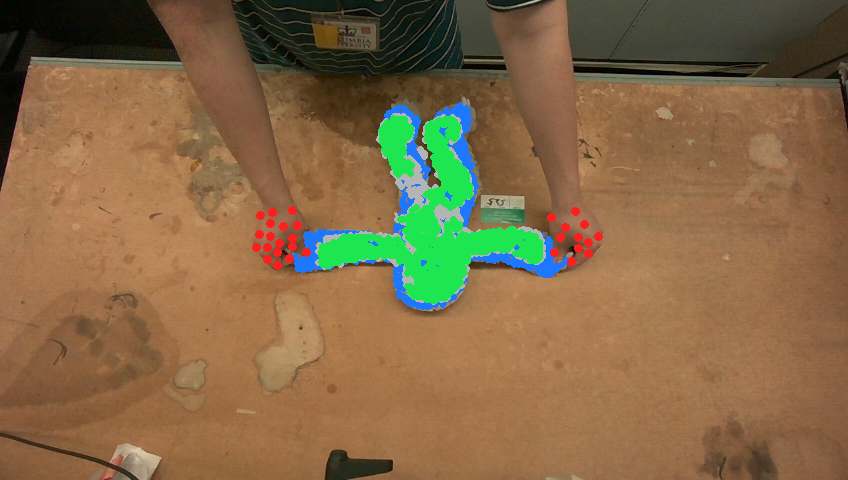

In [4]:

RUN = Path("/home/xinjie/single_proj_qqtt/result/demo_v4/qqtt_only_fake_live_20260625_181408")
CAP = RUN / "demo_v4_qqtt_only_demo32_capture_20260625_181451"
FINAL_DATA = RUN / "data/demo_v4_qqtt_only/final_data.pkl"

FRAME_IDX = 0

with open(FINAL_DATA, "rb") as f:
    data = pickle.load(f)

meta = json.loads((CAP / "metadata.json").read_text())
K = meta["intrinsics"]
fx, fy, cx, cy = K["fx"], K["fy"], K["cx"], K["cy"]

c2w = np.asarray(meta["camera_to_world_c2w"], dtype=np.float64)
w2c = np.linalg.inv(c2w)

frame = np.load(CAP / f"prepared_phystwin/{FRAME_IDX:06d}.npz")
rgb = frame["rgb_frame"]

def finite_points(points):
    pts = np.asarray(points, dtype=np.float64).reshape(-1, 3)
    return pts[np.isfinite(pts).all(axis=1)]

def project_world_points(points_w):
    pts_w = finite_points(points_w)
    if len(pts_w) == 0:
        return np.empty((0, 2), dtype=np.float64)

    pts_h = np.concatenate([pts_w, np.ones((len(pts_w), 1))], axis=1)
    pts_c = (w2c @ pts_h.T).T[:, :3]

    z = pts_c[:, 2]
    valid = z > 1e-6
    pts_c = pts_c[valid]
    z = z[valid]

    u = fx * pts_c[:, 0] / z + cx
    v = fy * pts_c[:, 1] / z + cy

    h, w = rgb.shape[:2]
    inside = (u >= 0) & (u < w) & (v >= 0) & (v < h)
    return np.stack([u[inside], v[inside]], axis=1)

def draw_points(image_rgb, points_w, color, radius=3):
    img = Image.fromarray(image_rgb.copy())
    draw = ImageDraw.Draw(img)
    uv = project_world_points(points_w)

    for u, v in uv:
        u, v = float(u), float(v)
        draw.ellipse(
            (u - radius, v - radius, u + radius, v + radius),
            fill=tuple(color),
        )
    return img, len(uv)

object_points = data["object_points"][FRAME_IDX]
controller_points = data["controller_points"][FRAME_IDX]
surface_points = data["surface_points"]
interior_points = data["interior_points"]

# 選你要疊哪一種
SHOW = "all"  # object / controller / surface / interior / all

img = Image.fromarray(rgb.copy())
counts = {}

if SHOW in ("object", "all"):
    img, counts["object"] = draw_points(np.asarray(img), object_points, (30, 120, 255), radius=2)

if SHOW in ("controller", "all"):
    img, counts["controller"] = draw_points(np.asarray(img), controller_points, (255, 30, 30), radius=4)

if SHOW in ("surface", "all"):
    img, counts["surface"] = draw_points(np.asarray(img), surface_points, (180, 180, 180), radius=3)

if SHOW in ("interior", "all"):
    img, counts["interior"] = draw_points(np.asarray(img), interior_points, (30, 230, 80), radius=3)

print(counts)
display(img)

In [7]:


CHUNKS_DIR = Path(
    "/home/xinjie/single_proj_qqtt/result/demo_v4/qqtt_only_fake_live_20260625_181408/"
    "online_data/demo_v4_qqtt_only/chunks"
)

POINT_STRIDE = 1
FPS = 30
POINT_SIZE = 8.0

OBJECT_COLOR = np.array([[0.0, 1.0, 0.0]])      # green
CONTROLLER_COLOR = np.array([[1.0, 0.0, 0.0]])  # red

chunks = []
for path in sorted(CHUNKS_DIR.glob("chunk_*.pkl")):
    with open(path, "rb") as f:
        chunks.append(pickle.load(f))

assert chunks, f"No chunks found in {CHUNKS_DIR}"

print("chunk count:", len(chunks))
print("first chunk keys:", chunks[0].keys())

object_points = np.concatenate([c["object_points"] for c in chunks], axis=0)
object_vis = np.concatenate([c["object_visibilities"] for c in chunks], axis=0)
controller_points = np.concatenate([c["controller_points"] for c in chunks], axis=0)

num_frames = object_points.shape[0]

print("frames:", num_frames)
print("object_points:", object_points.shape)
print("object_vis:", object_vis.shape)
print("controller_points:", controller_points.shape)

state = {
    "frame": 0,
    "playing": True,
    "last_time": time.time(),
}

object_pcd = o3d.geometry.PointCloud()
controller_pcd = o3d.geometry.PointCloud()

def set_frame(frame_idx):
    frame_idx %= num_frames
    state["frame"] = frame_idx

    visible = object_vis[frame_idx].astype(bool)
    pts = object_points[frame_idx][visible][::POINT_STRIDE]

    object_pcd.points = o3d.utility.Vector3dVector(pts.astype(np.float64))

    # object points: rainbow color by Y axis
    if pts.shape[0] > 0:
        y = pts[:, 1]
        y_norm = (y - y.min()) / (y.max() - y.min() + 1e-8)

        rainbow = np.stack([
            y_norm,
            1.0 - np.abs(y_norm - 0.5) * 2.0,
            1.0 - y_norm,
        ], axis=1)
    else:
        rainbow = np.empty((0, 3), dtype=np.float64)

    object_pcd.colors = o3d.utility.Vector3dVector(
        np.clip(rainbow, 0.0, 1.0).astype(np.float64)
    )

    # controller points: red
    ctrl = controller_points[frame_idx]
    controller_pcd.points = o3d.utility.Vector3dVector(ctrl.astype(np.float64))
    controller_pcd.colors = o3d.utility.Vector3dVector(
        np.tile(CONTROLLER_COLOR, (ctrl.shape[0], 1)).astype(np.float64)
    )

def toggle_play(vis):
    state["playing"] = not state["playing"]
    print("playing:", state["playing"])
    return False

def next_frame(vis):
    set_frame(state["frame"] + 1)
    vis.update_geometry(object_pcd)
    vis.update_geometry(controller_pcd)
    print("frame:", state["frame"])
    return False

def prev_frame(vis):
    set_frame(state["frame"] - 1)
    vis.update_geometry(object_pcd)
    vis.update_geometry(controller_pcd)
    print("frame:", state["frame"])
    return False

def close(vis):
    vis.close()
    return False

def animation_callback(vis):
    if not state["playing"]:
        return False

    now = time.time()
    if now - state["last_time"] >= 1.0 / FPS:
        state["last_time"] = now
        set_frame(state["frame"] + 1)
        vis.update_geometry(object_pcd)
        vis.update_geometry(controller_pcd)

    return False

set_frame(0)

vis = o3d.visualization.VisualizerWithKeyCallback()
vis.create_window(
    window_name="Tracker 3D - object green / controller red",
    width=1280,
    height=800,
)

vis.add_geometry(object_pcd)
vis.add_geometry(controller_pcd)

opt = vis.get_render_option()
opt.point_size = POINT_SIZE
opt.background_color = np.asarray([1.0, 1.0, 1.0])
opt.show_coordinate_frame = True
opt.point_color_option = o3d.visualization.PointColorOption.Color

# Set initial camera view
view = vis.get_view_control()
view.set_front([0.0, 0.0, -1.0])
view.set_up([0.0, -1.0, 0.0])
view.set_zoom(0.8)

vis.register_key_callback(ord(" "), toggle_play)
vis.register_key_callback(ord("N"), next_frame)
vis.register_key_callback(ord("P"), prev_frame)
vis.register_key_callback(ord("Q"), close)
vis.register_animation_callback(animation_callback)

print("Controls:")
print("  mouse drag: rotate")
print("  wheel: zoom")
print("  right/middle drag: pan")
print("  Space: play/pause")
print("  N: next frame")
print("  P: previous frame")
print("  Q: quit")

vis.run()
vis.destroy_window()

chunk count: 23
first chunk keys: dict_keys(['case_name', 'chunk_id', 'start_frame', 'end_frame', 'source_frame_indices', 'object_points', 'object_colors', 'object_visibilities', 'object_motions_valid', 'controller_points', 'topology_version', 'topology_hash', 'query_ids', 'query_semantic_labels', 'object_sample_query_ids', 'controller_sample_query_ids', 'controller_fps_indices', 'controller_selected_query_ids', 'object_sample_indices', 'object_selected_query_ids'])
frames: 805
object_points: (805, 2020, 3)
object_vis: (805, 2020)
controller_points: (805, 30, 3)
Controls:
  mouse drag: rotate
  wheel: zoom
  right/middle drag: pan
  Space: play/pause
  N: next frame
  P: previous frame
  Q: quit
